1단계: 데이터를 로드하고 전처리를 수행합니다...
2단계: 데이터 불균형 해소를 위한 Oversampling을 수행합니다...
3단계: 다양한 모델과 기법을 테스트합니다...
4단계: 원본 데이터 기반 RF 튜닝 중...
5단계: 오버샘플링 데이터 기반 RF 튜닝 중...

 [최종 성능 비교 결과: F1-Score 내림차순 정렬]


,Accuracy,Precision,Recall,F1_Score,ROC_AUC
Model,,,,,
Logistic (Oversampled),0.753247,0.611111,0.814815,0.698413,0.813704
RF (Tuned - Original),0.746753,0.615385,0.740741,0.672269,0.821111
Random Forest (Basic),0.779221,0.727273,0.592593,0.653061,0.819167
RF (Tuned - Oversampled),0.740260,0.620690,0.666667,0.642857,0.817407
SVC (Basic),0.740260,0.652174,0.555556,0.600000,0.796389
Logistic (Basic),0.707792,0.600000,0.500000,0.545455,0.812963
DecisionTree (Basic),0.681818,0.553191,0.481481,0.514851,0.635741


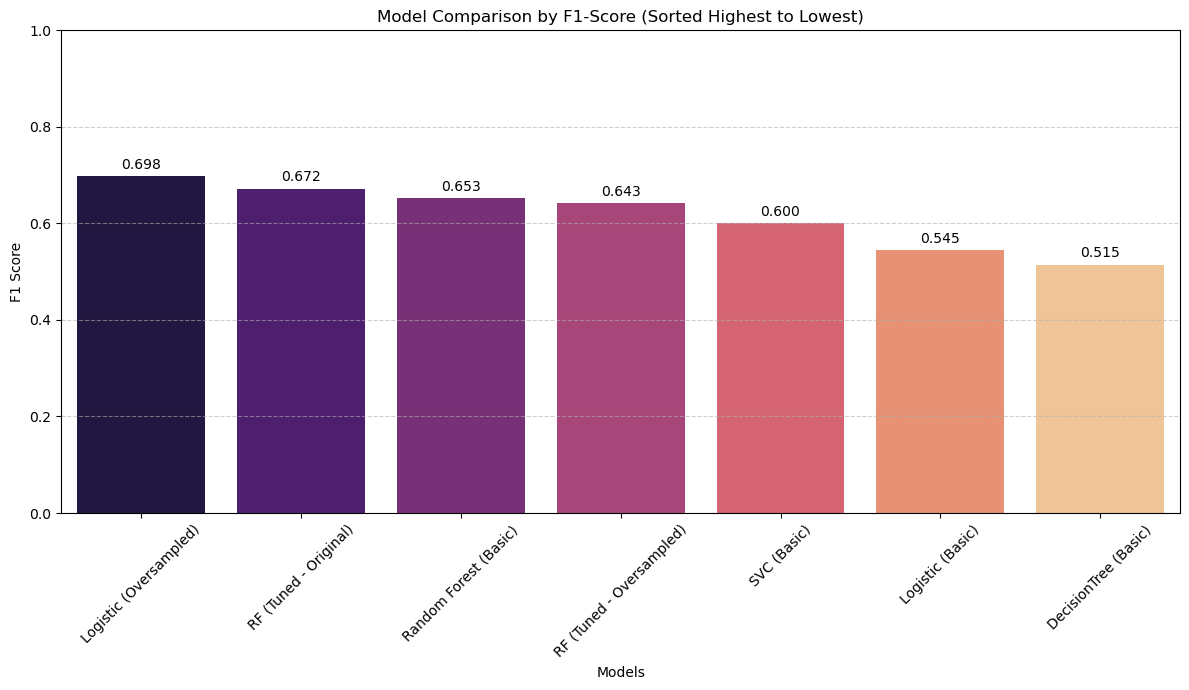

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 사이킷런 관련 임포트
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix)

import warnings
warnings.filterwarnings('ignore') # 실행 시 발생하는 경고 메시지 무시

# ---------------------------------------------------------
# 1. 데이터 로드 및 전처리
# ---------------------------------------------------------
print("1단계: 데이터를 로드하고 전처리를 수행합니다...")
df = pd.read_csv('pima-indians-diabetes-data.csv')

# 결측치(0) 처리: 임신 횟수 제외한 주요 수치들을 중앙값으로 대체
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 층화 추출(stratify) 적용하여 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링 (로지스틱 회귀, SVM 등 거리 기반 모델용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 2. Oversampling 수행 (Train 데이터 전용)
# ---------------------------------------------------------
print("2단계: 데이터 불균형 해소를 위한 Oversampling을 수행합니다...")
train_df = pd.concat([X_train, y_train], axis=1)
majority = train_df[train_df['Outcome'] == 0]
minority = train_df[train_df['Outcome'] == 1]

# 소수 클래스(환자)를 다수 클래스 개수만큼 복제
minority_over = minority.sample(n=len(majority), replace=True, random_state=42)
train_balanced = pd.concat([majority, minority_over], axis=0)

X_train_over = train_balanced.drop('Outcome', axis=1)
y_train_over = train_balanced['Outcome']

# Oversampling용 스케일링 데이터 준비
scaler_over = StandardScaler()
X_train_over_scaled = scaler_over.fit_transform(X_train_over)

# ---------------------------------------------------------
# 3. 통합 평가 함수 정의
# ---------------------------------------------------------
def evaluate_and_get_metrics(model, xtrain, xtest, ytrain, ytest, model_name):
    model.fit(xtrain, ytrain)
    y_pred = model.predict(xtest)
    y_prob = model.predict_proba(xtest) if hasattr(model, 'predict_proba') else None

    # 지표 계산
    roc_auc = roc_auc_score(ytest, y_prob[:, 1]) if y_prob is not None else "N/A"

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(ytest, y_pred),
        "Precision": precision_score(ytest, y_pred),
        "Recall": recall_score(ytest, y_pred),
        "F1_Score": f1_score(ytest, y_pred),
        "ROC_AUC": roc_auc
    }

# ---------------------------------------------------------
# 4. 모델 테스트 리스트 실행
# ---------------------------------------------------------
print("3단계: 다양한 모델과 기법을 테스트합니다...")
results_list = []

# (A) 기본 및 기법 적용 모델
results_list.append(evaluate_and_get_metrics(LogisticRegression(max_iter=2000), X_train_scaled, X_test_scaled, y_train, y_test, "Logistic (Basic)"))
results_list.append(evaluate_and_get_metrics(LogisticRegression(max_iter=2000), X_train_over_scaled, X_test_scaled, y_train_over, y_test, "Logistic (Oversampled)"))
results_list.append(evaluate_and_get_metrics(SVC(probability=True, random_state=42), X_train_scaled, X_test_scaled, y_train, y_test, "SVC (Basic)"))
results_list.append(evaluate_and_get_metrics(RandomForestClassifier(random_state=42), X_train, X_test, y_train, y_test, "Random Forest (Basic)"))
results_list.append(evaluate_and_get_metrics(DecisionTreeClassifier(random_state=42), X_train, X_test, y_train, y_test, "DecisionTree (Basic)"))

# (B) GridSearchCV 튜닝 (원본 vs 오버샘플링)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [2, 4],
    "max_features": ['sqrt']
}

print("4단계: 원본 데이터 기반 RF 튜닝 중...")
grid_orig = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_orig.fit(X_train, y_train)
results_list.append(evaluate_and_get_metrics(grid_orig.best_estimator_, X_train, X_test, y_train, y_test, "RF (Tuned - Original)"))

print("5단계: 오버샘플링 데이터 기반 RF 튜닝 중...")
grid_over = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_over.fit(X_train_over, y_train_over)
results_list.append(evaluate_and_get_metrics(grid_over.best_estimator_, X_train_over, X_test, y_train_over, y_test, "RF (Tuned - Oversampled)"))

# ---------------------------------------------------------
# 5. 최종 결과 비교 및 정렬 시각화
# ---------------------------------------------------------
# F1_Score 기준으로 내림차순 정렬
final_df = pd.DataFrame(results_list).set_index("Model")
final_df_sorted = final_df.sort_values(by="F1_Score", ascending=False)

print("\n" + "="*70)
print(" [최종 성능 비교 결과: F1-Score 내림차순 정렬]")
print("="*70)
display(final_df_sorted)

# 시각화: 정렬된 F1 Score 그래프
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=final_df_sorted.index, y=final_df_sorted['F1_Score'], palette='magma')

# 막대 위에 점수 라벨 표시
for i in ax.containers:
    ax.bar_label(i, fmt="%.3f", padding=3)

plt.xticks(rotation=45)
plt.title("Model Comparison by F1-Score (Sorted Highest to Lowest)")
plt.ylabel("F1 Score")
plt.xlabel("Models")
plt.ylim(0, 1.0) # 지표 범위를 0~1로 고정
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [2]:
# end